# Proyek Analisis Data: [Bike Sharing Dataset]
- **Nama:** Septa Bagas Setyawan
- **Email:** cdcc015d6y2100@student.devacademy.id
- **ID Dicoding:** CDCC015D6Y2100

## Menentukan Pertanyaan Bisnis

1. Berapa presentase perbedaan rata-rata penyewa sepeda penguna 'registered' pada jam (07:00-09:00 dan 17:00-19-00) diandingkan jam kerja biasa pada hari kerja (senin-Jumat) selama tahun 2012

2. Seberapa besar persentase penurunan rata-rata total penyewa harian (cnt) saat kondisi cuaca berubah dari Clear menjadi Light Snow selama musim dingin (winter) tahun 2011-2012

3. Berapa tingkat pertumbuhan pengguna 'caseal' di akhir pekan pada musin panas (Summer) dibandingkan musin semi (Spring) tahun 2012

## Import Semua Packages/Library yang Digunakan

In [94]:
import pandas as pd
pd.set_option('display.max_columns', None)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load df Day

In [95]:
day_df = pd.read_csv('/content/day.csv')
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


#### Load df Hour

In [96]:
hour_df  = pd.read_csv('/content/hour.csv')
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


### Assessing Data

#### Identifying Day problem

In [97]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [98]:
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [99]:
print("Jumlah duplikat: ", day_df.duplicated().sum())

Jumlah duplikat:  0


In [100]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [101]:
display(day_df[day_df['hum']==0])

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
68,69,2011-03-10,1,0,3,0,4,1,3,0.389091,0.385668,0.0,0.261877,46,577,623


**Steps to Take:**
- kolom instant sepertinya hanya angka urut, akan saya hapus
- menganti kolom hum 0 menjadi rata rata
- Data day cukup bersih namun dan saya perlu menambahkan kolom untuk label session, yr, mnth, weekday dan weathersit ini masih menggunakan kode dan sebaiknya saya tambahkan label agar mudah saat visualiasai
- Mengubah tipe data pada **dteday** dari object ke datetime
- mengubah kolom holiday dan workingday menjadi Boolean

#### Identifying Hour problem

In [102]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [103]:
hour_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [104]:
print("Jumlah duplikat: ", hour_df.duplicated().sum())

Jumlah duplikat:  0


In [105]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [106]:
display(hour_df[hour_df['hum']==0])

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
1551,1552,2011-03-10,1,0,3,0,0,4,1,3,0.34,0.3182,0.0,0.2537,3,0,3
1552,1553,2011-03-10,1,0,3,1,0,4,1,3,0.34,0.3182,0.0,0.2537,0,2,2
1553,1554,2011-03-10,1,0,3,2,0,4,1,3,0.34,0.3182,0.0,0.2537,0,1,1
1554,1555,2011-03-10,1,0,3,5,0,4,1,3,0.36,0.3485,0.0,0.1940,1,2,3
1555,1556,2011-03-10,1,0,3,6,0,4,1,3,0.36,0.3333,0.0,0.3284,0,12,12
1556,1557,2011-03-10,1,0,3,7,0,4,1,3,0.38,0.3939,0.0,0.2239,1,36,37
1557,1558,2011-03-10,1,0,3,8,0,4,1,3,0.38,0.3939,0.0,0.2836,1,43,44
1558,1559,2011-03-10,1,0,3,9,0,4,1,3,0.40,0.4091,0.0,0.2239,1,23,24
1559,1560,2011-03-10,1,0,3,10,0,4,1,3,0.40,0.4091,0.0,0.1642,0,17,17
1560,1561,2011-03-10,1,0,3,11,0,4,1,3,0.40,0.4091,0.0,0.2537,6,5,11


In [107]:
(hour_df['hum']==0).sum()

np.int64(22)

**Steps to Take:**
- kolom instant sepertinya hanya angka urut, akan saya hapus
- menganti kolom hum 0 menjadi rata rata
- Data hour juga cukup bersih dan saya perlu menambahkan kolom untuk label session, yr, mnth, weekday dan weathersit ini masih menggunakan kode dan sebaiknya saya tambahkan label agar mudah saat visualiasai
- Mengubah tipe data pada **dteday** dari object ke datetime
- mengubah kolom holiday dan workingday menjadi Boolean

### Cleaning Data

#### Fixing day problem

In [108]:
day_df.drop('instant', axis=1, inplace=True)

In [109]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])

In [110]:
seasion_mapping = {
    1: 'springer',
    2: 'summer',
    3: 'fall',
    4: 'winter'
}

day_df['season_label'] = day_df['season'].map(seasion_mapping)

In [111]:
yr_mapping = {
    0: '2011',
    1: '2012'
}

day_df['yr_label'] = day_df['yr'].map(yr_mapping)

day_df['yr_label'] = day_df['yr_label'].astype(int)

In [112]:
mnth_mapping = {
    1: 'January',
    2: 'February',
    3: 'March',
    4: 'April',
    5: 'May',
    6: 'June',
    7: 'July',
    8: 'August',
    9: 'September',
    10: 'October',
    11: 'November',
    12: 'December'
}

day_df['mnth_label'] = day_df['mnth'].map(mnth_mapping)

In [113]:
weekday_mapping = {
    0: 'Sunday',
    1: 'Monday',
    2: 'Tuesday',
    3: 'Wednesday',
    4: 'Thursday',
    5: 'Friday',
    6: 'Saturday'
}

day_df['weekday_label'] = day_df['weekday'].map(weekday_mapping)

In [114]:
day_df['holiday'] = day_df['holiday'].astype(bool)

In [115]:
day_df['workingday'] = day_df['workingday'].astype(bool)

In [116]:
weathersit_mapping = {
    1: 'Clear',
    2: 'Mist',
    3: 'Light Rain',
    4: 'Heavy Rain'
}

day_df['weathersit_label'] = day_df['weathersit'].map(weathersit_mapping)

In [117]:
display(day_df[day_df['hum']==0])

,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,season_label,yr_label,mnth_label,weekday_label,weathersit_label
68,2011-03-10,1,0,3,False,4,True,3,0.389091,0.385668,0.0,0.261877,46,577,623,springer,2011,March,Thursday,Light Rain


In [118]:
rata_rata_hum = day_df['hum'].mean()
day_df.loc[day_df['hum']==0, 'hum'] = rata_rata_hum

In [119]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   dteday            731 non-null    datetime64[ns]
 1   season            731 non-null    int64         
 2   yr                731 non-null    int64         
 3   mnth              731 non-null    int64         
 4   holiday           731 non-null    bool          
 5   weekday           731 non-null    int64         
 6   workingday        731 non-null    bool          
 7   weathersit        731 non-null    int64         
 8   temp              731 non-null    float64       
 9   atemp             731 non-null    float64       
 10  hum               731 non-null    float64       
 11  windspeed         731 non-null    float64       
 12  casual            731 non-null    int64         
 13  registered        731 non-null    int64         
 14  cnt               731 non-

In [120]:
day_df.describe()

,dteday,season,yr,mnth,weekday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,yr_label
count,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,2012-01-01 00:00:00,2.496580,0.500684,6.519836,2.997264,1.395349,0.495385,0.474354,0.628753,0.190486,848.176471,3656.172367,4504.348837,2011.500684
min,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,1.000000,0.059130,0.079070,0.187917,0.022392,2.000000,20.000000,22.000000,2011.000000
25%,2011-07-02 12:00:00,2.000000,0.000000,4.000000,1.000000,1.000000,0.337083,0.337842,0.521041,0.134950,315.500000,2497.000000,3152.000000,2011.000000
50%,2012-01-01 00:00:00,3.000000,1.000000,7.000000,3.000000,1.000000,0.498333,0.486733,0.627500,0.180975,713.000000,3662.000000,4548.000000,2012.000000
75%,2012-07-01 12:00:00,3.000000,1.000000,10.000000,5.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000,2012.000000
max,2012-12-31 00:00:00,4.000000,1.000000,12.000000,6.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000,2012.000000
std,NaN,1.110807,0.500342,3.451913,2.004787,0.544894,0.183051,0.162961,0.140518,0.077498,686.622488,1560.256377,1937.211452,0.500342


**Insight:**
- Data semakin rapi dan siap dianalisis lanjut dan visualisasi
- Tentang weathersit nilai max adalah 3, atinya tidak ada cuaca extrim

#### Fixing hour problem

In [121]:
hour_df.drop('instant', axis=1, inplace=True)

In [122]:
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

In [123]:
session_mapping = {
    1: 'springer',
    2: 'summer',
    3: 'fall',
    4: 'winter'
}

hour_df['season_label'] = hour_df['season'].map(seasion_mapping)

In [124]:
yr_mapping = {
    0: '2011',
    1: '2012'
}

hour_df['yr_label'] = hour_df['yr'].map(yr_mapping)

hour_df['yr_label'] = hour_df['yr_label'].astype(int)

In [125]:
mnth_mapping = {
    1: 'January',
    2: 'February',
    3: 'March',
    4: 'April',
    5: 'May',
    6: 'June',
    7: 'July',
    8: 'August',
    9: 'September',
    10: 'October',
    11: 'November',
    12: 'December'
}

hour_df['mnth_label'] = hour_df['mnth'].map(mnth_mapping)

In [126]:
weekday_mapping = {
    0: 'Sunday',
    1: 'Monday',
    2: 'Tuesday',
    3: 'Wednesday',
    4: 'Thursday',
    5: 'Friday',
    6: 'Saturday'
}

hour_df['weekday_label'] = hour_df['weekday'].map(weekday_mapping)

In [127]:
hour_df['holiday'] = hour_df['holiday'].astype(bool)

In [128]:
hour_df['workingday'] = hour_df['workingday'].astype(bool)

In [129]:
weathersit_mapping = {
    1: 'Clear',
    2: 'Mist',
    3: 'Light Rain',
    4: 'Heavy Rain'
}

hour_df['weathersit_label'] = hour_df['weathersit'].map(weathersit_mapping)

In [130]:
rata_rata_hum = hour_df['hum'].mean()
hour_df.loc[hour_df['hum']==0, 'hum'] = rata_rata_hum

In [131]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   dteday            17379 non-null  datetime64[ns]
 1   season            17379 non-null  int64         
 2   yr                17379 non-null  int64         
 3   mnth              17379 non-null  int64         
 4   hr                17379 non-null  int64         
 5   holiday           17379 non-null  bool          
 6   weekday           17379 non-null  int64         
 7   workingday        17379 non-null  bool          
 8   weathersit        17379 non-null  int64         
 9   temp              17379 non-null  float64       
 10  atemp             17379 non-null  float64       
 11  hum               17379 non-null  float64       
 12  windspeed         17379 non-null  float64       
 13  casual            17379 non-null  int64         
 14  registered        1737

In [132]:
hour_df.describe()

,dteday,season,yr,mnth,hr,weekday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,yr_label
count,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,2012-01-02 04:08:34.552045568,2.501640,0.502561,6.537775,11.546752,3.003683,1.425283,0.496987,0.475775,0.628023,0.190098,35.676218,153.786869,189.463088,2011.502561
min,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.080000,0.000000,0.000000,0.000000,1.000000,2011.000000
25%,2011-07-04 00:00:00,2.000000,0.000000,4.000000,6.000000,1.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000,2011.000000
50%,2012-01-02 00:00:00,3.000000,1.000000,7.000000,12.000000,3.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000,2012.000000
75%,2012-07-02 00:00:00,3.000000,1.000000,10.000000,18.000000,5.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000,2012.000000
max,2012-12-31 00:00:00,4.000000,1.000000,12.000000,23.000000,6.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000,2012.000000
std,NaN,1.106918,0.500008,3.438776,6.914405,2.005771,0.639357,0.192556,0.171850,0.191633,0.122340,49.305030,151.357286,181.387599,0.500008


## Exploratory Data Analysis (EDA)

### Explore Day

In [133]:
day_df.describe(include="all")

,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,season_label,yr_label,mnth_label,weekday_label,weathersit_label
count,731,731.000000,731.000000,731.000000,731,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731,731.000000,731,731,731
unique,NaN,NaN,NaN,NaN,2,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,12,7,3
top,NaN,NaN,NaN,NaN,False,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fall,NaN,January,Saturday,Clear
freq,NaN,NaN,NaN,NaN,710,NaN,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,188,NaN,62,105,463
mean,2012-01-01 00:00:00,2.496580,0.500684,6.519836,NaN,2.997264,NaN,1.395349,0.495385,0.474354,0.628753,0.190486,848.176471,3656.172367,4504.348837,NaN,2011.500684,NaN,NaN,NaN
min,2011-01-01 00:00:00,1.000000,0.000000,1.000000,NaN,0.000000,NaN,1.000000,0.059130,0.079070,0.187917,0.022392,2.000000,20.000000,22.000000,NaN,2011.000000,NaN,NaN,NaN
25%,2011-07-02 12:00:00,2.000000,0.000000,4.000000,NaN,1.000000,NaN,1.000000,0.337083,0.337842,0.521041,0.134950,315.500000,2497.000000,3152.000000,NaN,2011.000000,NaN,NaN,NaN
50%,2012-01-01 00:00:00,3.000000,1.000000,7.000000,NaN,3.000000,NaN,1.000000,0.498333,0.486733,0.627500,0.180975,713.000000,3662.000000,4548.000000,NaN,2012.000000,NaN,NaN,NaN
75%,2012-07-01 12:00:00,3.000000,1.000000,10.000000,NaN,5.000000,NaN,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000,NaN,2012.000000,NaN,NaN,NaN
max,2012-12-31 00:00:00,4.000000,1.000000,12.000000,NaN,6.000000,NaN,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000,NaN,2012.000000,NaN,NaN,NaN


In [134]:
pertahun = day_df.groupby('yr_label')[['casual', 'registered', 'cnt']].sum()
display(pertahun)

,casual,registered,cnt
yr_label,,,
2011,247252,995851,1243103
2012,372765,1676811,2049576


In [135]:
perbulan = day_df.groupby('mnth_label')[['casual', 'registered', 'cnt']].sum()
perbulan = perbulan.sort_values(by='cnt', ascending=False)
display(perbulan)

,casual,registered,cnt
mnth_label,,,
August,72039,279155,351194
June,73906,272436,346342
September,70323,275668,345991
July,78157,266791,344948
May,75285,256401,331686
October,59760,262592,322352
April,60802,208292,269094
November,36603,218228,254831
March,44444,184476,228920


In [136]:
percuaca = day_df.groupby('weathersit_label')[['casual', 'registered', 'cnt']].sum()
percuaca = percuaca.sort_values(by='cnt', ascending=False)
display(percuaca)

,casual,registered,cnt
weathersit_label,,,
Clear,446346,1811606,2257952
Mist,169776,827082,996858
Light Rain,3895,33974,37869


In [137]:
harikerja = day_df.groupby('workingday')[['casual', 'registered', 'cnt']].sum()
harikerja = harikerja.sort_values(by='cnt', ascending=False)
display(harikerja)

,casual,registered,cnt
workingday,,,
True,303285,1989125,2292410
False,316732,683537,1000269


**Insight:** (Opsional)
- pada kolom weathersit_label ternyata cuaca ekstrem pernah terjadi!, namun hanya berlangsung selama beberapa jam tidak 24 jam penuh
- ternyata pada weathersit hanya ada 3 yang unique, artinya memang benar bahwa cuaca ekstrem tidak pernah terjadi
- weathersit yang sering terjadi yaitu clear/cerah sebanyak 463 dari 731
- penjualan terlaris saat hari kerja saat cuaca cerah

### Explore Hour

In [138]:
hour_df.describe(include="all")

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,season_label,yr_label,mnth_label,weekday_label,weathersit_label
count,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379,17379.000000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379,17379.000000,17379,17379,17379
unique,NaN,NaN,NaN,NaN,NaN,2,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,12,7,4
top,NaN,NaN,NaN,NaN,NaN,False,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fall,NaN,July,Saturday,Clear
freq,NaN,NaN,NaN,NaN,NaN,16879,NaN,11865,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4496,NaN,1488,2512,11413
mean,2012-01-02 04:08:34.552045568,2.501640,0.502561,6.537775,11.546752,NaN,3.003683,NaN,1.425283,0.496987,0.475775,0.628023,0.190098,35.676218,153.786869,189.463088,NaN,2011.502561,NaN,NaN,NaN
min,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,NaN,0.000000,NaN,1.000000,0.020000,0.000000,0.080000,0.000000,0.000000,0.000000,1.000000,NaN,2011.000000,NaN,NaN,NaN
25%,2011-07-04 00:00:00,2.000000,0.000000,4.000000,6.000000,NaN,1.000000,NaN,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000,NaN,2011.000000,NaN,NaN,NaN
50%,2012-01-02 00:00:00,3.000000,1.000000,7.000000,12.000000,NaN,3.000000,NaN,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000,NaN,2012.000000,NaN,NaN,NaN
75%,2012-07-02 00:00:00,3.000000,1.000000,10.000000,18.000000,NaN,5.000000,NaN,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000,NaN,2012.000000,NaN,NaN,NaN
max,2012-12-31 00:00:00,4.000000,1.000000,12.000000,23.000000,NaN,6.000000,NaN,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000,NaN,2012.000000,NaN,NaN,NaN


In [139]:
pertahun = hour_df.groupby('yr_label')[['casual', 'registered', 'cnt']].sum()
display(pertahun)

,casual,registered,cnt
yr_label,,,
2011,247252,995851,1243103
2012,372765,1676811,2049576


In [140]:
perbulan = hour_df.groupby('mnth_label')[['casual', 'registered', 'cnt']].sum()
perbulan = perbulan.sort_values(by='cnt', ascending=False)
display(perbulan)

,casual,registered,cnt
mnth_label,,,
August,72039,279155,351194
June,73906,272436,346342
September,70323,275668,345991
July,78157,266791,344948
May,75285,256401,331686
October,59760,262592,322352
April,60802,208292,269094
November,36603,218228,254831
March,44444,184476,228920


In [141]:
percuaca = hour_df.groupby('weathersit_label')[['casual', 'registered', 'cnt']].sum()
percuaca = percuaca.sort_values(by='cnt', ascending=False)
display(percuaca)

,casual,registered,cnt
weathersit_label,,,
Clear,462745,1875428,2338173
Mist,134481,661471,795952
Light Rain,22783,135548,158331
Heavy Rain,8,215,223


In [142]:
harikerja = hour_df.groupby('workingday')[['casual', 'registered', 'cnt']].sum()
harikerja = harikerja.sort_values(by='cnt', ascending=False)
display(harikerja)

,casual,registered,cnt
workingday,,,
True,303285,1989125,2292410
False,316732,683537,1000269


In [143]:
perjam = hour_df.groupby('hr')[['casual', 'registered', 'cnt']].sum()
perjam = perjam.sort_values(by='cnt', ascending=False).head(10)
display(perjam)

,casual,registered,cnt
hr,,,
17,54220,282640,336860
18,44496,265276,309772
8,15761,245240,261001
16,53834,173914,227748
19,35505,191284,226789
13,52713,132206,184919
12,49718,134696,184414
15,54606,128543,183149
14,55089,120563,175652


**Insight:** (Opsional)
- pada kolom weathersit_label ternyata cuaca ekstrem pernah terjadi!, namun hanya berlangsung selama beberapa jam tidak 24 jam penuh
- ternyata pada weathersit hanya ada 3 yang unique, artinya memang benar bahwa cuaca ekstrem tidak pernah terjadi
- weathersit yang sering terjadi yaitu clear/cerah sebanyak 463 dari 731
- penjualan terlaris saat hari kerja saat cuaca cerah

## Visualization & Explanatory Analysis

### Pertanyaan 1: Berapa presentase perbedaan rata-rata penyewa sepeda penguna 'registered' pada jam (07:00-09:00 dan 17:00-19-00) diandingkan jam kerja biasa pada hari kerja (senin-Jumat) selama tahun 2012

In [144]:
hour_df['yr_label'].unique()

array([2011, 2012])

In [145]:
data_2012 = hour_df[(hour_df['yr_label'] == 2012)&(hour_df['workingday'] == True)].copy() # Filter data

def kategori_jam(jam):
    if (7 <= jam <= 9) or (17<= jam <= 19):
        return 'rush_hour'
    else:
        return 'non_rush_hour'

data_2012['kategori_jam'] = data_2012['hr'].apply(kategori_jam) # Kategori jam

rata2 = data_2012.groupby('kategori_jam')['registered'].mean()

rush = rata2.loc['rush_hour']
non_rush = rata2.loc['non_rush_hour'] # Rata-rata

presentase = ((rush - non_rush)/non_rush)*100
print(f"presentase perbedaan: {presentase:.2f}%")

presentase perbedaan: 257.02%


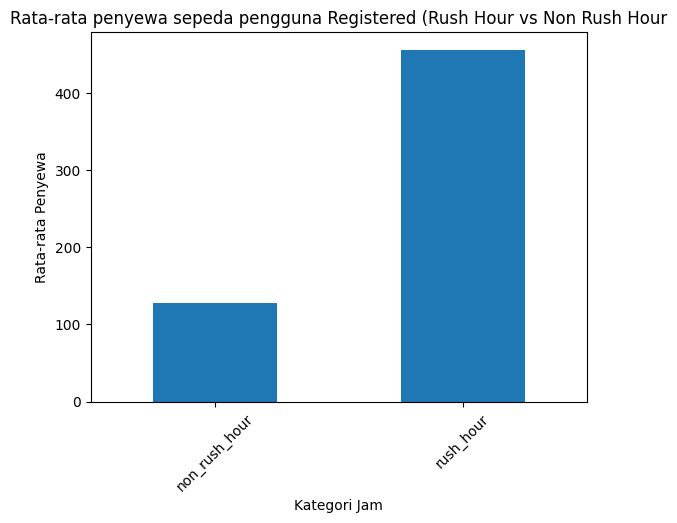

In [146]:
rata2.plot(kind='bar')

plt.title('Rata-rata penyewa sepeda pengguna Registered (Rush Hour vs Non Rush Hour')
plt.xlabel('Kategori Jam')
plt.ylabel('Rata-rata Penyewa')
plt.xticks(rotation=45)
plt.show()

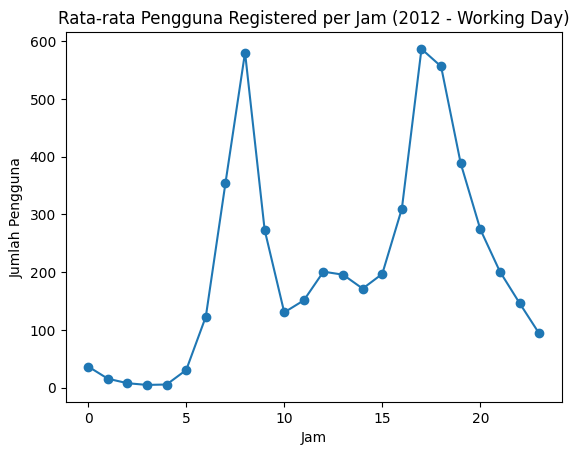

In [147]:
hour_df[
    (hour_df['yr_label'] == 2012) &
    (hour_df['workingday'] == True)
].groupby('hr')['registered'].mean().plot(marker='o')

plt.title("Rata-rata Pengguna Registered per Jam (2012 - Working Day)")
plt.xlabel("Jam")
plt.ylabel("Jumlah Pengguna")
plt.show()

### Pertanyaan 2: seberapa besar persentase penurunan rata-rata total penyewa harian (cnt) saat kondisi cuaca berubah dari Clear menjadi Light Snow selama musim dingin (winter) tahun 2011-2012

In [148]:
data_winter = day_df[day_df['season_label'] == 'winter'].copy() # Filter

clear = data_winter[data_winter['weathersit_label'] == 'Clear']['cnt'].mean()
light_snow = data_winter[data_winter['weathersit_label'] == 'Light Rain']['cnt'].mean()

penurunan = ((clear - light_snow)/clear)*100
print(f"Persentase penurunan: {penurunan:.2f}%")

Persentase penurunan: 61.11%


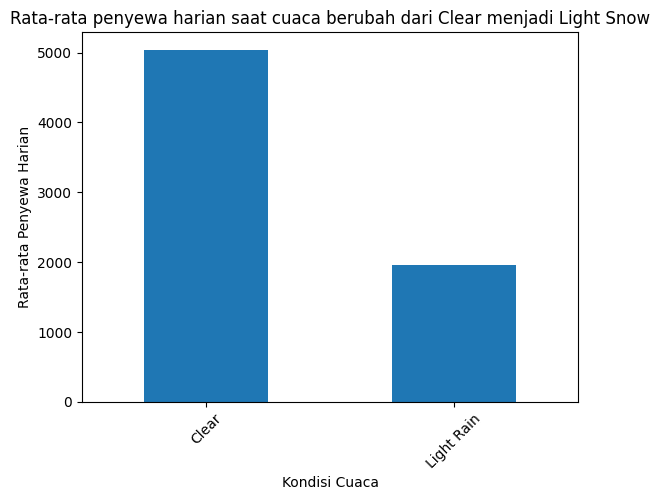

In [149]:
rata2_weather = data_winter.groupby('weathersit_label')['cnt'].mean()

rata2_weather.loc[['Clear', 'Light Rain']].plot(kind='bar')

plt.title('Rata-rata penyewa harian saat cuaca berubah dari Clear menjadi Light Snow')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Rata-rata Penyewa Harian')
plt.xticks(rotation=45)
plt.show()

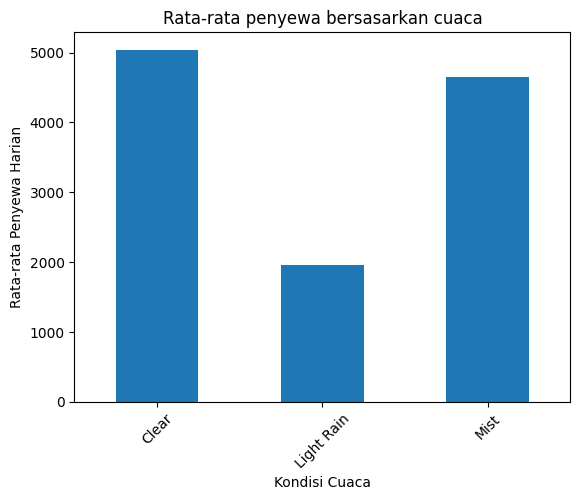

In [150]:
data_winter.groupby('weathersit_label')['cnt'].mean().plot(kind='bar')

plt.title('Rata-rata penyewa bersasarkan cuaca')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Rata-rata Penyewa Harian')
plt.xticks(rotation=45)
plt.show()

### Pertanyaan 3: Berapa tingkat pertumbuhan pengguna 'caseal' di akhir pekan pada musin panas (Summer) dibandingkan musin semi (Spring) tahun 2012

In [151]:
data_2012_weekend = day_df[
    (day_df['yr_label'] == 2012) &
    (day_df['workingday'] == False)].copy() # Filter

spring = data_2012_weekend[data_2012_weekend['season_label'] == 'springer']['casual'].mean()
summer = data_2012_weekend[data_2012_weekend['season_label'] == 'summer']['casual'].mean()

growth = ((summer - spring)/spring)*100
print(f"Tingkat Growth: {growth:.2f}%")

Tingkat Growth: 252.32%


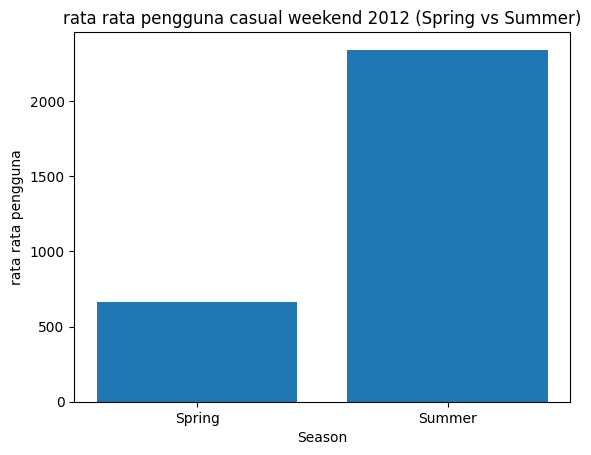

In [152]:
labels = ['Spring','Summer']
values = [spring, summer]

plt.bar(labels, values)

plt.title('rata rata pengguna casual weekend 2012 (Spring vs Summer)')
plt.xlabel('Season')
plt.ylabel('rata rata pengguna')
plt.show()

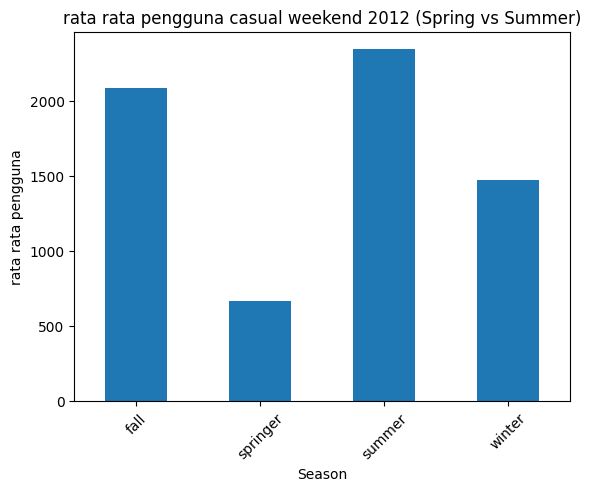

In [153]:
data_2012_weekend.groupby('season_label')['casual'].mean().plot(kind='bar')

plt.title('rata rata pengguna casual weekend 2012 (Spring vs Summer)')
plt.xlabel('Season')
plt.ylabel('rata rata pengguna')
plt.xticks(rotation=45)
plt.show()

**Insight:** (Opsional)
- berdasarkan visualisasi menunjukkan bahwa rata-rata pengguna registered meningkat signifikan pada jam sibuk, dengan puncak pada pagi dan sore. ini menunjukkan bahwa penggunaan sepeda didominasi oleh aktivitas commuting
- Rata-rata penyewaan sepeda menurun signifikan saat kondisi cuaca berubah dari cerah menjadi hujan/salju ringan, dengan penurunan sebesar 61.11%
- jumlah pengguna casual meningkat signifikan pada musim panas (summer) dibandingkan musim semi

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** rata-rata pengguna Registered pada jam sibuk (07:00-09:00 dan 17:00-19:00) di hari kerja pada tahun 2012 meningkat sebesar 257.02% dibandingkan jam kerja biasa, Hal ini menunjukkan bahwa penggunaan sepeda didominasi oleh aktivitas commuting(perjalanan berangkat dan pulang kerja)

- **Conclusion pertanyaan 2:** Terjadi penurunan rata-rata penyewaan sepeda sebesar 61.11% ketika kondisi cuaca berubah dari Clear menjadi Light Rain pada musim dingin. Ini menunjukkan bahwa kondisi cuaca memiliki dampak yang signifikan terhadap minat pengguna sepeda

- **Conclusion pertanyaan 3:** Pengguna sepeda casual menalami peningkatan pada akhir pekan di musim panas dibandingkan musin semi. Hal ini menunjukkan bahwa pengguna sepeda casual menggunakan untuk aktivitas rekreasi yang dipengaruhi oleh kondisi cuaca dan musin

**Rekomendasi Action Item:**
- Optimalkan operasional saat Rush Hour, tambahkan jumlah sepeda pada jam sibuk, dan pastikan ketersediaan sepeda di area perkantoran
- pada saat cuaca buruk berikan promo dan sediakan jas hujan
- maksimalkan weekend di musim panas serta berikan promo, fokus di area wisata dan taman
- strateginya adalah sepeda registered untuk commuting, dan sepeda casual untuk santai

In [154]:
day_df.to_csv("day.csv", index=False)

In [155]:
hour_df.to_csv("hour.csv", index=False)